In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [4]:
def solve_numerov_array(V_array, h, m=1.0, hbar=1.0, k=3):
    """
    Solves the 1D Schrodinger equation using the Numerov matrix method.
    Returns the lowest `k` eigenvalues and eigenvectors.
    """
    N_int = len(V_array)
    off_diag = np.ones(N_int - 1)

    # Build sparse tridiagonal matrices for interior points
    A = (1.0 / h**2) * sp.diags([off_diag, -2.0 * np.ones(N_int), off_diag], [-1, 0, 1])
    B = sp.diags([off_diag / 12.0, 10.0 / 12.0 * np.ones(N_int), off_diag / 12.0], [-1, 0, 1])

    V = sp.diags(V_array)
    LHS_matrix = -(hbar**2 / (2 * m)) * A + B @ V

    # Solve generalized eigenvalue problem: LHS * x = E * B * x
    # We use shift-invert mode (sigma) to find the lowest algebraic eigenvalues reliably
    evals, evecs = spla.eigsh(LHS_matrix, k=k, M=B, sigma=np.min(V_array) - 1e-3)

    p = np.argsort(evals)
    return evals[p], evecs[:, p]

def cumtrapz(y, dx):
    """Cumulative trapezoidal numerical integration."""
    int_y = np.zeros_like(y)
    for i in range(1, len(y)):
        int_y[i] = int_y[i-1] + 0.5 * (y[i-1] + y[i]) * dx
    return int_y

In [5]:
# Setup the physical parameters and the initial guess (Li2+)
Z = 3.0
dr = 0.01
xs = np.arange(1e-15, 20.0 + dr, dr)
N = len(xs)
m = 1.0
hbar = 1.0
hartree_to_eV = 27.211386

# Step 1: Get the bare Li2+ 1s and 2s states as our starting guess
V_bare = -Z / xs
evals_bare, evecs_bare = solve_numerov_array(V_bare[1:-1], dr, m, hbar, k=3)

# Initialize storage arrays
# phi[0] -> Electron 1 (1s)
# phi[1] -> Electron 2 (1s)
# phi[2] -> Electron 3 (2s)
phi = np.zeros((3, N))
E = np.zeros(3)

# Seed two electrons in 1s, one in 2s
for i in range(3):
    if i < 2:
        phi[i, 1:-1] = evecs_bare[:, 0] / np.sqrt(dr)
        E[i] = evals_bare[0]
    else:
        phi[i, 1:-1] = evecs_bare[:, 1] / np.sqrt(dr)
        E[i] = evals_bare[1]

print(f"Iteration 0 Energies (eV): [{E[0]*hartree_to_eV:.2f}, {E[1]*hartree_to_eV:.2f}, {E[2]*hartree_to_eV:.2f}]")

Iteration 0 Energies (eV): [-122.38, -122.38, -30.60]


In [6]:
"""
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Implement the Hartree Self-Consistent Field (SCF) Iteration Procedure.

Instructions:
1. The outer loop handles the iterations (k=1 to 5).
2. Inside, loop over each electron `i` (from 0 to 2).
3. Calculate the charge density `rho` of the OTHER two electrons.
   (rho is the sum of the squared absolute values of their wavefunctions).
4. Calculate the enclosed charge `Qenc` using `cumtrapz(rho, dr)`.
5. Construct the effective potential `V_eff` for electron `i`:
   V_eff = V_nucleus + V_electron_repulsion = -Z / xs + Qenc / xs
6. Solve the radial Schrödinger equation using `solve_numerov_array` with `V_eff[1:-1]`.
7. Update the energy `E[i]` and wavefunction `phi[i]`!
   *CRITICAL*: Electrons 0 and 1 are in the 1s state.
               Electron 2 is in the 2s state. Select the right eigenvalue/vector.
8. Enforce sign consistency (if phi[i, 1] < 0, multiply phi[i] by -1).
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""

for k in range(1, 6):
    for i in range(3):
        rho = np.zeros(N)
        
        # --- YOUR CODE HERE ---
        
        
        
        # ----------------------
        
    print(f"Iteration {k} Energies (eV): [{E[0]*hartree_to_eV:.2f}, {E[1]*hartree_to_eV:.2f}, {E[2]*hartree_to_eV:.2f}]")

Iteration 1 Energies (eV): [-122.38, -122.38, -30.60]
Iteration 2 Energies (eV): [-122.38, -122.38, -30.60]
Iteration 3 Energies (eV): [-122.38, -122.38, -30.60]
Iteration 4 Energies (eV): [-122.38, -122.38, -30.60]
Iteration 5 Energies (eV): [-122.38, -122.38, -30.60]


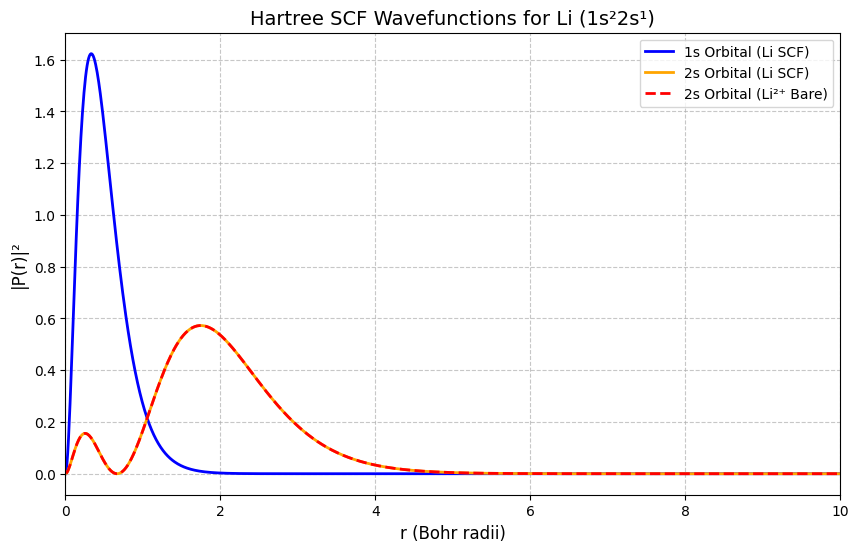

In [7]:
# Plotting the SCF Wavefunctions
plt.figure(figsize=(10, 6))
plt.title("Hartree SCF Wavefunctions for Li (1s²2s¹)", fontsize=14)
plt.xlabel("r (Bohr radii)", fontsize=12)
plt.ylabel("|P(r)|²", fontsize=12)
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot our converged Hartree states
plt.plot(xs, np.abs(phi[0, :])**2, label="1s Orbital (Li SCF)", color='blue', lw=2)
plt.plot(xs, np.abs(phi[2, :])**2, label="2s Orbital (Li SCF)", color='orange', lw=2)

# Plot the bare Li2+ state for comparison
# Note: The bare 2s was stored at index 1 of the initial solver
plt.plot(xs[1:-1], np.abs(evecs_bare[:, 1] / np.sqrt(dr))**2,
         label="2s Orbital (Li²⁺ Bare)", color='red', linestyle='--', lw=2)

plt.legend()
plt.show()